In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation
from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
DATA_PATH = "D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt"

file = glob.glob(f"{DATA_PATH}")
file

['D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt']

In [3]:
# Load keypoints from output.txt and display shape
keypoints = np.loadtxt(file[0])
print('Keypoints shape:', keypoints.shape)

def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

Keypoints shape: (181, 56)


In [4]:
coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

def plot_line(axs, pt1, pt2, **kwargs):
    """
    Plots a line between two points on the given matplotlib axis.
    pt1, pt2: (x, y) tuples or arrays
    axs: matplotlib axis object
    kwargs: additional arguments for axs.plot (e.g., color, linewidth)
    """
    x_values = [pt1[0], pt2[0]]
    y_values = [pt1[1], pt2[1]]
    axs.plot(x_values, y_values, **kwargs)

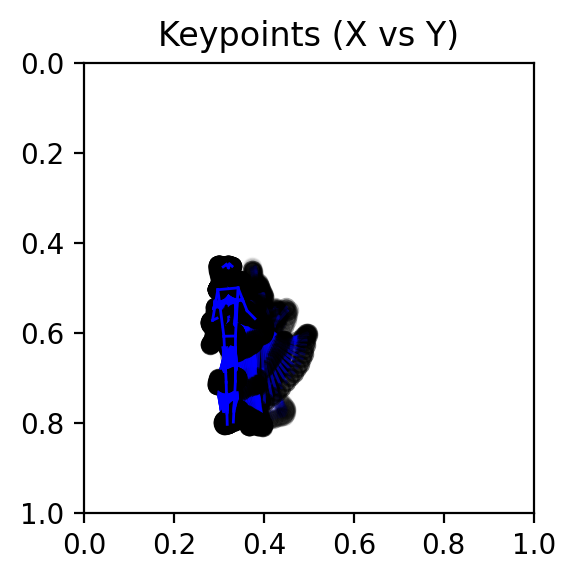

In [5]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
alpha = 0
nodes = np.zeros([180,17,2])
edges = np.zeros([180,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(180):
    alpha += 1.0 / 180  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha = alpha)  # Plot keypoints as red dots
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    for i in range(16):
        plot_line(axs, edges[t][i][0], edges[t][i][1], color='blue', linewidth=1, alpha=alpha)  # Plot edges as blue lines

axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
axs.set_title('Keypoints (X vs Y)')
plt.tight_layout()
plt.show()

In [6]:
def calculate_node_velocity(nodes, dt=1.0):
    """
    Calculate the velocity of each node over time.
    nodes: numpy array of shape (frames, num_nodes, 2) with (x, y) positions.
    dt: time difference between frames (default 1.0, set to actual frame interval if known).
    Returns:
        velocities: numpy array of shape (frames-1, num_nodes, 2) with (vx, vy) velocities.
        speeds: numpy array of shape (frames-1, num_nodes) with speed magnitudes.
    """
    velocities = (nodes[1:] - nodes[:-1]) / dt
    speeds = np.linalg.norm(velocities, axis=2)
    return velocities, speeds

**DATASET**

In [7]:
import numpy as np
import torch
import glob
import os
from torch.utils.data import Dataset

def normalize(data, data_max, data_min):
    return (data - data_min) * 2 / (data_max - data_min) - 1

def unnormalize(data, data_max, data_min):
    return (data + 1) * (data_max - data_min) / 2 + data_min

import numpy as np
import torch
import glob
import os
from torch.utils.data import Dataset

def normalize(data, data_max, data_min):
    return (data - data_min) * 2 / (data_max - data_min) - 1

def unnormalize(data, data_max, data_min):
    return (data + 1) * (data_max - data_min) / 2 + data_min

class PoseDataset(Dataset):
    # Removed pitch_type from the init arguments
    def __init__(self, data_path, mode, data_len=-1, test_full=False):
        self.data_path = data_path
        self.mode = mode
        self.train_data_len = data_len
        self.test_full = test_full

        # 1. Use the '*' wildcard to grab files from ALL pitch type subfolders
        train_files = glob.glob(os.path.join(data_path, 'train', '*', '*.txt'))
        if not train_files:
            raise ValueError(f"No training files found in {os.path.join(data_path, 'train')}")
            
        train_locs, train_vels = self._load_and_process_files(train_files)

        # 2. Calculate min/max values across the entire training set for normalization
        self.loc_max = max(loc.max() for loc in train_locs)
        self.loc_min = min(loc.min() for loc in train_locs)
        self.vel_max = max(vel.max() for vel in train_vels)
        self.vel_min = min(vel.min() for vel in train_vels)

        # 3. Load the requested split (train, val, or test)
        if mode == 'train':
            split_locs, split_vels = train_locs, train_vels
        else:
            # Use the wildcard '*' here as well
            split_files = glob.glob(os.path.join(data_path, mode, '*', '*.txt'))
            
            # Safeguard
            if not split_files:
                raise ValueError(f"No {mode} files found in directory: {os.path.join(data_path, mode)}. Please check your folder structure!")
                
            split_locs, split_vels = self._load_and_process_files(split_files)

        # 4. Normalize and build the final feature tensors
        self.feat = []
        for loc, vel in zip(split_locs, split_vels):
            loc_norm = normalize(loc, self.loc_max, self.loc_min)
            vel_norm = normalize(vel, self.vel_max, self.vel_min)
            
            # Concatenate loc and vel into shape: (frames, 17, 4)
            combined = np.concatenate([loc_norm, vel_norm], axis=-1).astype(np.float32)
            
            # Truncate test sequences if requested
            if self.mode == 'test' and not self.test_full:
                combined = combined[:49]
                
            self.feat.append(torch.from_numpy(combined))

    def _load_and_process_files(self, file_paths):
        """Helper to load .txt files, extract 17 keypoints, and compute velocity."""
        all_locs = []
        all_vels = []
        
        for file_path in file_paths:
            # Load text file -> shape: (frames, 56)
            data = np.loadtxt(file_path)
            frames = data.shape[0]
            
            # Extract x, y coordinates for the 17 nodes
            loc = np.zeros((frames, 17, 2))
            for i in range(17):
                loc[:, i, 0] = data[:, 5 + i*3]      # x coordinate
                loc[:, i, 1] = data[:, 5 + i*3 + 1]  # y coordinate
                
            # Calculate velocities (forward difference)
            vel = np.zeros_like(loc)
            vel[1:] = loc[1:] - loc[:-1]  # Assuming dt=1.0 per frame
            
            all_locs.append(loc)
            all_vels.append(vel)
            
        return all_locs, all_vels

    def __getitem__(self, index):
        inputs = self.feat[index]

        # Slice sequences if a target length is specified
        if self.train_data_len > 0:
            size = len(inputs)
            if size > self.train_data_len:
                if self.mode == 'train':
                    # Random crop for data augmentation during training
                    start_ind = np.random.randint(0, size - self.train_data_len)
                else:
                    # Deterministic crop for consistent validation/testing
                    start_ind = 0 
                inputs = inputs[start_ind:start_ind + self.train_data_len]

        return {'inputs': inputs}

    def __len__(self):
        return len(self.feat)

In [8]:
DATA_PATH = "D:/GitHub/BaseballPitch/data/finetuning_dataset/labels"
DATA_LEN = 176 # Adjust to your chosen sequence length

# Clean and simple, no pitch_type required
train_data = PoseDataset(DATA_PATH, 'train', data_len=DATA_LEN)
val_data = PoseDataset(DATA_PATH, 'val', data_len=DATA_LEN)
test_data = PoseDataset(DATA_PATH, 'test', data_len=DATA_LEN, test_full=True)

**NRI MODEL**

In [9]:
def encode_onehot(labels):
    """Convert labels to one-hot encoding."""
    unique_labels = sorted(set(labels))
    onehot = np.eye(len(unique_labels))
    return onehot[np.searchsorted(unique_labels, labels)]

class RefNRIMLP(nn.Module):
    """Two-layer fully-connected ELU net with optional batch norm."""

    def __init__(self, n_in, n_hid, n_out, dropout_prob=0., no_bn=False):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_in, n_hid),
            nn.ELU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(n_hid, n_out),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(n_out) if not no_bn else nn.Identity()
        )

        # Initialize weights
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                m.bias.data.fill_(0.1)
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        # Reshape if needed for BatchNorm
        orig_shape = x.shape
        if len(orig_shape) > 2:
            x = x.view(-1, orig_shape[-1])

        x = self.net(x)

        # Restore original shape if needed
        if len(orig_shape) > 2:
            x = x.view(*orig_shape[:-1], -1)

        return x

In [10]:
class BaseNRI(nn.Module):
    def __init__(self, num_vars, encoder, decoder,
                num_edge_types=2,
                gumbel_temp=0.5,
                prior_variance=5e-5,
                kl_coef=1.0):
        super().__init__()
        self.num_vars = num_vars
        self.encoder = encoder
        self.decoder = decoder
        self.num_edge_types = num_edge_types
        self.gumbel_temp = gumbel_temp
        self.prior_variance = prior_variance
        self.kl_coef = kl_coef

        # Initialize prior distribution
        prior = torch.zeros(num_edge_types).fill_(1.0 / num_edge_types)
        self.log_prior = torch.log(prior).unsqueeze(0).unsqueeze(0)
        self.log_prior = self.log_prior.cuda(non_blocking=True)

    def _compute_nll(self, preds, target):
        neg_log_p = (preds - target) ** 2 / (2 * self.prior_variance)
        const = 0.5 * np.log(2 * np.pi * self.prior_variance)
        return (neg_log_p.sum(-1) + const).view(preds.size(0), -1).mean(dim=1)

    def _compute_kl(self, probs):
        kl = probs * (torch.log(probs + 1e-16) - self.log_prior)
        return kl.sum(-1).view(probs.size(0), -1).mean(dim=1)

    def calculate_loss(self, inputs, is_train=False, teacher_forcing=True,
                        return_edges=False, return_logits=False):
        # Get encoder outputs and sample edges
        logits = self.encoder(inputs)['logits']
        edges = F.gumbel_softmax(logits.view(-1, self.num_edge_types),
                                tau=self.gumbel_temp,
                                hard=not is_train).view(logits.shape)

        # Get predictions and calculate losses
        output = self.decoder(inputs[:, :-1], edges)
        target = inputs[:, 1:, :, :] if len(inputs.shape) > 3 else inputs[:, 1:]

        loss_nll = self._compute_nll(output, target)
        loss_kl = self._compute_kl(F.softmax(logits, dim=-1))
        loss = (loss_nll + self.kl_coef * loss_kl).mean()

        if return_edges:
            return loss, loss_nll, loss_kl, edges
        elif return_logits:
            return loss, loss_nll, loss_kl, logits, output
        return loss, loss_nll, loss_kl

    def predict_future(self, inputs, prediction_steps,
                        return_edges=False, return_everything=False):
        logits = self.encoder(inputs)['logits']
        edges = F.gumbel_softmax(logits.view(-1, self.num_edge_types),
                                tau=self.gumbel_temp,
                                hard=True).view(logits.shape)

        tmp_predictions, decoder_state = self.decoder(
            inputs[:, :-1], edges, return_state=True)

        predictions = self.decoder(
            inputs[:, -1].unsqueeze(1), edges,
            prediction_steps=prediction_steps,
            teacher_forcing=False,
            state=decoder_state)

        if return_everything:
            predictions = torch.cat([tmp_predictions, predictions], dim=1)

        return (predictions, edges) if return_edges else predictions

**ENCODER MODEL**

In [11]:
class BaseEncoder(nn.Module):
    def __init__(self, num_vars):
        super(BaseEncoder, self).__init__()
        self.num_vars = num_vars
        edges = torch.ones(num_vars)- torch.eye(num_vars)
        self.send_edges, self.recv_edges = torch.where(edges)

        one_hot_recv = torch.nn.functional.one_hot(
                                                self.recv_edges,
                                                num_classes=num_vars
                                                )
        self.edge2node_mat = nn.Parameter(one_hot_recv.float().T, requires_grad=False)

    def node2edge(self, node_embeddings):
        send_embed = node_embeddings[:, self.send_edges]
        recv_embed = node_embeddings[:, self.recv_edges]
        
        return torch.cat([send_embed, recv_embed], dim=2)

    def edge2node(self, edge_embeddings):
        incoming = torch.matmul(self.edge2node_mat, edge_embeddings)
        
        return incoming / (self.num_vars - 1)

    def forward(self, inputs, state=None, return_state=False):
        raise NotImplementedError

In [12]:
class RefMLPEncoder(BaseEncoder):
    def __init__(self,
            num_vars=17,
            input_size=4,
            input_time_steps=50,
            encoder_mlp_hidden=256,
            encoder_hidden=256,
            num_edge_types=2,
            encoder_dropout=0.):
        super(RefMLPEncoder, self).__init__(num_vars)
        inp_size = input_size * input_time_steps
        hidden_size = encoder_hidden
        num_layers = 3
        self.input_time_steps = input_time_steps

        self.mlp1 = RefNRIMLP(inp_size, hidden_size, hidden_size, encoder_dropout)
        self.mlp2 = RefNRIMLP(hidden_size*2, hidden_size,hidden_size, encoder_dropout)
        self.mlp3 = RefNRIMLP(hidden_size, hidden_size,hidden_size, encoder_dropout)
        mlp4_inp_size = hidden_size * 2
        self.mlp4 = RefNRIMLP(mlp4_inp_size, hidden_size,hidden_size, encoder_dropout)

        layers = [nn.Linear(hidden_size, encoder_mlp_hidden), nn.ELU(inplace=True)]
        layers += [nn.Linear(encoder_mlp_hidden, encoder_mlp_hidden),
                  nn.ELU(inplace=True)] * (num_layers - 2)
        layers.append(nn.Linear(encoder_mlp_hidden, num_edge_types))
        self.fc_out = nn.Sequential(*layers)
        self.init_weights()


    def node2edge(self, node_embeddings):
        send_embed = node_embeddings[:, self.send_edges, :]
        recv_embed = node_embeddings[:, self.recv_edges, :]
        return torch.cat([send_embed, recv_embed], dim=2)

    def edge2node(self, edge_embeddings):
        incoming = torch.matmul(self.edge2node_mat, edge_embeddings)
        return incoming/(self.num_vars-1)

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                m.bias.data.fill_(0.1)

    def merge_states(self, states):
        return torch.cat(states, dim=0)

    def forward(self, inputs, state=None, return_state=False):
            if inputs.size(1) > self.input_time_steps:
                inputs = inputs[:, -self.input_time_steps:]
            elif inputs.size(1) < self.input_time_steps:
                begin_inp = inputs[:, 0:1].expand(
                -1,
                self.input_time_steps-inputs.size(1),
                -1, -1
                )
                inputs = torch.cat([begin_inp, inputs], dim=1)

            x = inputs.transpose(1, 2).contiguous()
            x = x.view(inputs.size(0), inputs.size(2), -1)

            x = self.mlp1(x)
            x = self.node2edge(x)
            x = self.mlp2(x)

            x = self.edge2node(x)
            x = self.mlp3(x)

            x = self.node2edge(x)
            x = self.mlp4(x)

            result =  self.fc_out(x)
            result_dict = {
                'logits': result,
                'state': inputs,
                }
            return result_dict

**DECODER**

In [13]:
class CustomGRU(nn.Module):
    def __init__(self, input_size, n_hid, num_vars=17):
        super(CustomGRU, self).__init__()
        self.num_vars = num_vars

        # Hidden state transformations
        self.hidden_r = nn.Linear(n_hid, n_hid, bias=False)
        self.hidden_i = nn.Linear(n_hid, n_hid, bias=False)
        self.hidden_h = nn.Linear(n_hid, n_hid, bias=False)

        # Input transformations
        self.input_r = nn.Linear(input_size, n_hid, bias=True)
        self.input_i = nn.Linear(input_size, n_hid, bias=True)
        self.input_n = nn.Linear(input_size, n_hid, bias=True)

    def forward(self, inputs, agg_msgs, hidden):
        # Reshape inputs
        inp_r = self.input_r(inputs).view(inputs.size(0), self.num_vars, -1)
        inp_i = self.input_i(inputs).view(inputs.size(0), self.num_vars, -1)
        inp_n = self.input_n(inputs).view(inputs.size(0), self.num_vars, -1)

        # GRU operations
        r = torch.sigmoid(inp_r + self.hidden_r(agg_msgs))
        i = torch.sigmoid(inp_i + self.hidden_i(agg_msgs))
        n = torch.tanh(inp_n + r * self.hidden_h(agg_msgs))
        hidden = (1 - i) * n + i * hidden

        return hidden

In [14]:
class GraphRNNDecoder(nn.Module):
    def __init__(self, num_vars=17, input_size=4, decoder_dropout=0.,
                decoder_hidden=64, num_edge_types=2, skip_first=True):
        super(GraphRNNDecoder, self).__init__()
        self.num_vars = num_vars
        self.msg_out_shape = decoder_hidden
        self.skip_first_edge_type = skip_first
        self.dropout_prob = decoder_dropout
        self.edge_types = num_edge_types

        # Message passing networks
        self.msg_fc1 = nn.ModuleList([
            nn.Linear(2 * decoder_hidden, decoder_hidden)
            for _ in range(self.edge_types)
        ])
        self.msg_fc2 = nn.ModuleList([
            nn.Linear(decoder_hidden, decoder_hidden)
            for _ in range(self.edge_types)
        ])

        # Custom GRU cell
        self.custom_gru = CustomGRU(input_size, decoder_hidden)

        # Output networks
        self.out_fc1 = nn.Linear(decoder_hidden, decoder_hidden)
        self.out_fc2 = nn.Linear(decoder_hidden, decoder_hidden)
        self.out_fc3 = nn.Linear(decoder_hidden, input_size)

        # Edge connectivity setup
        edges = np.ones(num_vars) - np.eye(num_vars)
        self.send_edges = np.where(edges)[0]
        self.recv_edges = np.where(edges)[1]
        self.edge2node_mat = torch.FloatTensor(encode_onehot(self.recv_edges))
        self.edge2node_mat = self.edge2node_mat.cuda(non_blocking=True)

    def single_step_forward(self, inputs, rel_type, hidden):
        # Get receivers and senders
        receivers = hidden[:, self.recv_edges, :]
        senders = hidden[:, self.send_edges, :]
        pre_msg = torch.cat([receivers, senders], dim=-1)

        # Initialize message tensor
        all_msgs = torch.zeros(
            pre_msg.size(0), pre_msg.size(1),
            self.msg_out_shape, device=inputs.device
        )

        # Message passing
        start_idx = 1 if self.skip_first_edge_type else 0
        norm = float(len(self.msg_fc2) - start_idx)

        for i in range(start_idx, len(self.msg_fc2)):
            msg = torch.tanh(self.msg_fc1[i](pre_msg))
            msg = F.dropout(msg, p=self.dropout_prob)
            msg = torch.tanh(self.msg_fc2[i](msg))
            msg = msg * rel_type[:, :, i:i+1]
            all_msgs += msg / norm

        # Aggregate messages
        agg_msgs = all_msgs.transpose(-2, -1)
        agg_msgs = agg_msgs.matmul(self.edge2node_mat)
        agg_msgs = agg_msgs.transpose(-2, -1) / (self.num_vars - 1)

        # Update hidden state
        hidden = self.custom_gru(inputs, agg_msgs, hidden)

        # Generate prediction
        pred = F.dropout(F.relu(self.out_fc1(hidden)), p=self.dropout_prob)
        pred = F.dropout(F.relu(self.out_fc2(pred)), p=self.dropout_prob)
        pred = self.out_fc3(pred)

        pred = inputs + pred
        return pred, hidden

    def forward(self, inputs, sampled_edges,
                teacher_forcing=False,
                teacher_forcing_steps=-1,
                return_state=False,
                prediction_steps=-1,
                state=None):
        batch_size, time_steps, num_vars, num_feats = inputs.size()
        pred_steps = prediction_steps if prediction_steps > 0 else time_steps

        # Expand sampled edges if needed
        if len(sampled_edges.shape) == 3:
            sampled_edges = sampled_edges.unsqueeze(1)
            sampled_edges = sampled_edges.expand(batch_size, pred_steps, -1, -1)

        # Initialize hidden state
        if state is None:
            hidden = torch.zeros(
                batch_size, num_vars,
                self.msg_out_shape, device=inputs.device
            )
        else:
            hidden = state
        teacher_forcing_steps = time_steps

        # Generate predictions
        pred_all = []
        for step in range(pred_steps):
            if step == 0 or (teacher_forcing and step < teacher_forcing_steps):
                ins = inputs[:, step, :]
            else:
                ins = pred_all[-1]

            pred, hidden = self.single_step_forward(
                ins, sampled_edges[:, step, :], hidden
            )
            pred_all.append(pred)

        preds = torch.stack(pred_all, dim=1)
        return (preds, hidden) if return_state else preds

**TRAINING**

In [15]:
num_vars = 17
input_features = 4  # x, y, vx, vy
encoder_time_steps = 50  # This matches the burn_in_steps in your eval loop

# Build Encoder with explicit dataset shapes
encoder = RefMLPEncoder(
    num_vars=num_vars, 
    input_size=input_features, 
    input_time_steps=encoder_time_steps
)
print("ENCODER: ", encoder)

# Build Decoder with explicit dataset shapes
decoder = GraphRNNDecoder(
    num_vars=num_vars, 
    input_size=input_features
)
print("DECODER: ", decoder)

model = BaseNRI(num_vars, encoder, decoder)
model = model.cuda()

ENCODER:  RefMLPEncoder(
  (mlp1): RefNRIMLP(
    (net): Sequential(
      (0): Linear(in_features=200, out_features=256, bias=True)
      (1): ELU(alpha=1.0, inplace=True)
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): ELU(alpha=1.0, inplace=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (mlp2): RefNRIMLP(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): ELU(alpha=1.0, inplace=True)
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): ELU(alpha=1.0, inplace=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (mlp3): RefNRIMLP(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ELU(alpha=1.0, inplace=True)
      (2): Dropout(p=0.0, inplace=Fal

In [16]:
gpu = True
batch_size = 8
val_batch_size = batch_size

num_epochs = 100

clip_grad = None
clip_grad_norm = None
val_teacher_forcing = True
tune_on_nll = True

train_data_loader = DataLoader(train_data,
                                batch_size=batch_size,
                                shuffle=True,
                                drop_last=True)

val_data_loader = DataLoader(val_data, batch_size=val_batch_size)
lr = 5e-4
decay_factor = 0.5
decay_steps = 300
wd = 0.

def build_scheduler(opt, lr_decay_factor=0.5, lr_decay_steps=300):
    if lr_decay_factor:
        return torch.optim.lr_scheduler.StepLR(opt, lr_decay_steps, lr_decay_factor)
    else:
        return None


In [17]:
model_params = [param for param in model.parameters() if param.requires_grad]
opt = torch.optim.Adam(model_params, lr=lr, weight_decay=wd)

start_epoch = 1
best_val_epoch = -1
best_val_result = 10000000
training_scheduler = build_scheduler(opt)

end = start = 0

import random
def seed(seed_val):
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    random.seed(seed_val)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_val)

seed(1)

In [18]:
from tqdm import tqdm

pbar = tqdm(range(start_epoch, num_epochs + 1), desc='Epochs')
for epoch in pbar:
    model.train()
    model.train_percent = epoch / num_epochs
    total_training_loss = 0

    for batch in train_data_loader:
        inputs = batch['inputs']
        if gpu:
            inputs = inputs.cuda(non_blocking=True)

        loss, loss_nll, loss_kl, logits, _ = model.calculate_loss(
            inputs,
            is_train=True,
            return_logits=True
        )
        loss.backward()

        # Handling gradient clipping
        if clip_grad is not None:
            nn.utils.clip_grad_value_(model.parameters(), clip_grad)
        elif clip_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

        opt.step()
        opt.zero_grad()
        total_training_loss += loss.item()

    if training_scheduler is not None:
        training_scheduler.step()

    # Validation phase
    model.eval()
    total_nll, total_kl = 0, 0

    with torch.no_grad():
        for batch in val_data_loader:
            inputs = batch['inputs']
            if gpu:
                inputs = inputs.cuda(non_blocking=True)

            _, loss_nll, loss_kl, _, _ = model.calculate_loss(
                inputs,
                is_train=False,
                teacher_forcing=val_teacher_forcing,
                return_logits=True
            )
            total_kl += loss_kl.sum().item()
            total_nll += loss_nll.sum().item()

    total_kl /= len(val_data)
    total_nll /= len(val_data)
    total_loss = model.kl_coef * total_kl + total_nll

    tuning_loss = total_nll if tune_on_nll else total_loss

    if tuning_loss < best_val_result:
        best_val_epoch, best_val_result = epoch, tuning_loss

    # Update progress bar with metrics
    pbar.set_postfix({
        'train_loss': f'{total_training_loss:.4f}',
        'val_loss': f'{tuning_loss:.4f}',
        'best_val': f'{best_val_result:.4f}'
    })

Epochs:  45%|████▌     | 45/100 [1:46:39<2:10:21, 142.21s/it, train_loss=28872.4625, val_loss=129.9346, best_val=125.5703]


KeyboardInterrupt: 

**TESTING**

In [ ]:
def eval_forward_prediction(model, dataset, burn_in_steps, forward_pred_steps, gpu=True, batch_size=8, return_total_errors=False):
    dataset.return_edges = False

    data_loader = DataLoader(dataset, batch_size=batch_size, pin_memory=gpu)
    model.eval()
    total_se = 0
    batch_count = 0
    all_errors = []
    for batch_ind, batch in enumerate(data_loader):
        inputs = batch['inputs']
        with torch.no_grad():
            model_inputs = inputs[:, :burn_in_steps]
            gt_predictions = inputs[:, burn_in_steps:burn_in_steps+forward_pred_steps]
            if gpu:
                model_inputs = model_inputs.cuda(non_blocking=True)
            model_preds = model.predict_future(model_inputs, forward_pred_steps).cpu()
            batch_count += 1
            if return_total_errors:
                all_errors.append(F.mse_loss(model_preds, gt_predictions, reduction='none').view(model_preds.size(0), model_preds.size(1), -1).mean(dim=-1))
            else:
                total_se += F.mse_loss(model_preds, gt_predictions, reduction='none').view(model_preds.size(0), model_preds.size(1), -1).mean(dim=-1).sum(dim=0)
    if return_total_errors:
        return torch.cat(all_errors, dim=0)
    else:
        return total_se / len(dataset)

In [ ]:
test_data = PoseDataset(DATA_PATH, 'test', data_len=DATA_LEN, test_full=True)
mode='eval'
if mode == 'eval':
    test_cumulative_mse = eval_forward_prediction(model, test_data, 110, 66)

    test_mse_1 = test_cumulative_mse[0].item()
    test_mse_20 = test_cumulative_mse[19].item()
    test_mse_40 = test_cumulative_mse[39].item()
    print("FORWARD PRED RESULTS:")
    print("\t1 STEP:  ",test_mse_1)
    print("\t20 STEP: ", test_mse_20)
    print("\t40 STEP: ",test_mse_40)

FORWARD PRED RESULTS:
	1 STEP:   0.00014693403500132263
	20 STEP:  0.019590331241488457
	40 STEP:  0.025558210909366608


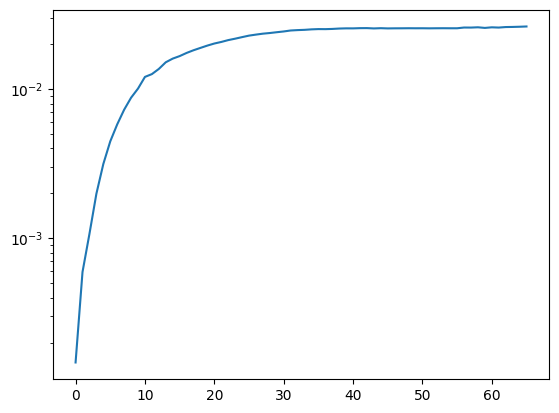

In [ ]:
import matplotlib.pyplot as plt
plt.semilogy(test_cumulative_mse)

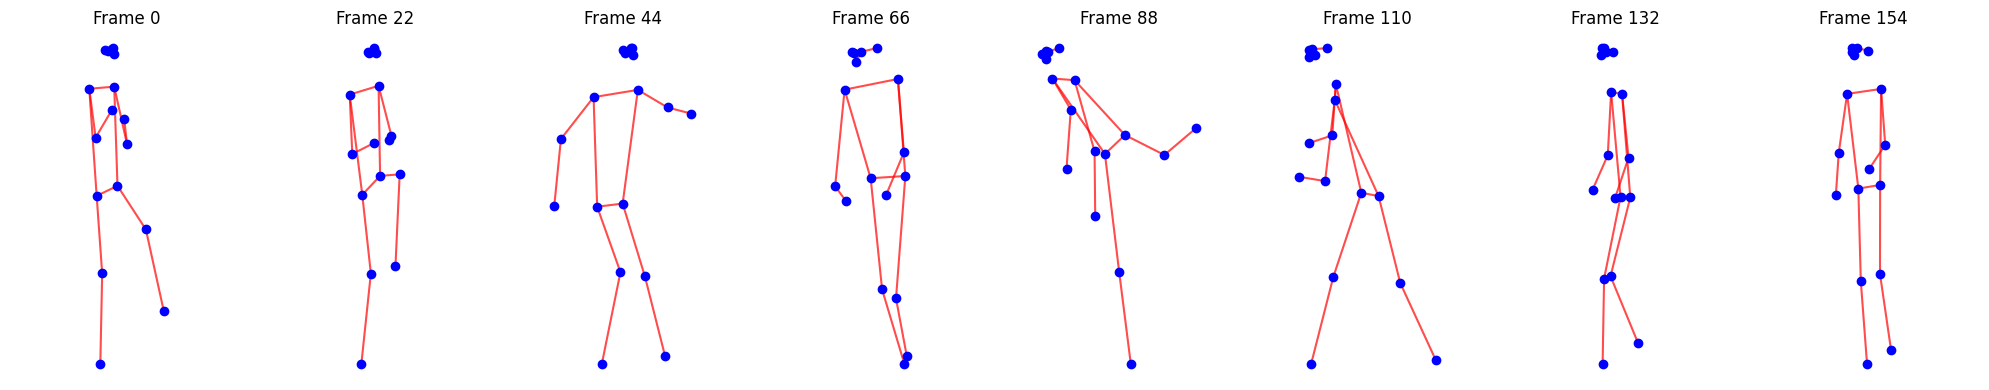

In [ ]:
def plot_frame(positions, edges, title="Motion Frame"):
    plt.figure(figsize=(8, 8))

    for i, j in edges:
        plt.plot([positions[i, 2], positions[j, 2]],
                [-positions[i, 1], -positions[j, 1]], 'r-', alpha=0.7)

    plt.scatter(positions[:, 2], -positions[:, 1], c='blue', zorder=2)

    plt.title(title)
    plt.axis('equal')
    plt.grid(True)

nodes = np.zeros([180,17,2])
edges = np.zeros([180,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(180):
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]

# Get entire test sequence
sample = test_data[0]['inputs']  # Shape: [180, 17, 4]

plt.figure(figsize=(20, 4)) # Slightly wider figure to fit 9 frames comfortably

# Iterate over 9 frames
for idx, frame_num in enumerate(range(0, DATA_LEN, DATA_LEN//8), 1):
    ax = plt.subplot(1, 8, idx) # Changed from 5 to 9 columns

    # Grab just the X and Y coordinates (indices 0 and 1)
    positions = sample[frame_num, :, :2]
    
    if isinstance(positions, torch.Tensor):
        positions = positions.numpy()

    # Loop through your integer index pairs, not the raw edges matrix!
    for i, j in coco_connections:
        plt.plot([positions[i, 0], positions[j, 0]],
                [positions[i, 1], positions[j, 1]], 'r-', alpha=0.7)

    # Scatter plot using index 0 for X and 1 for Y
    plt.scatter(positions[:, 0], positions[:, 1], c='blue', zorder=2)

    plt.title(f'Frame {frame_num}')
    plt.axis('equal')
    
    # Invert the Y-axis so the pitcher is right-side up
    ax.invert_yaxis()
    
    # Remove ticks and boxes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

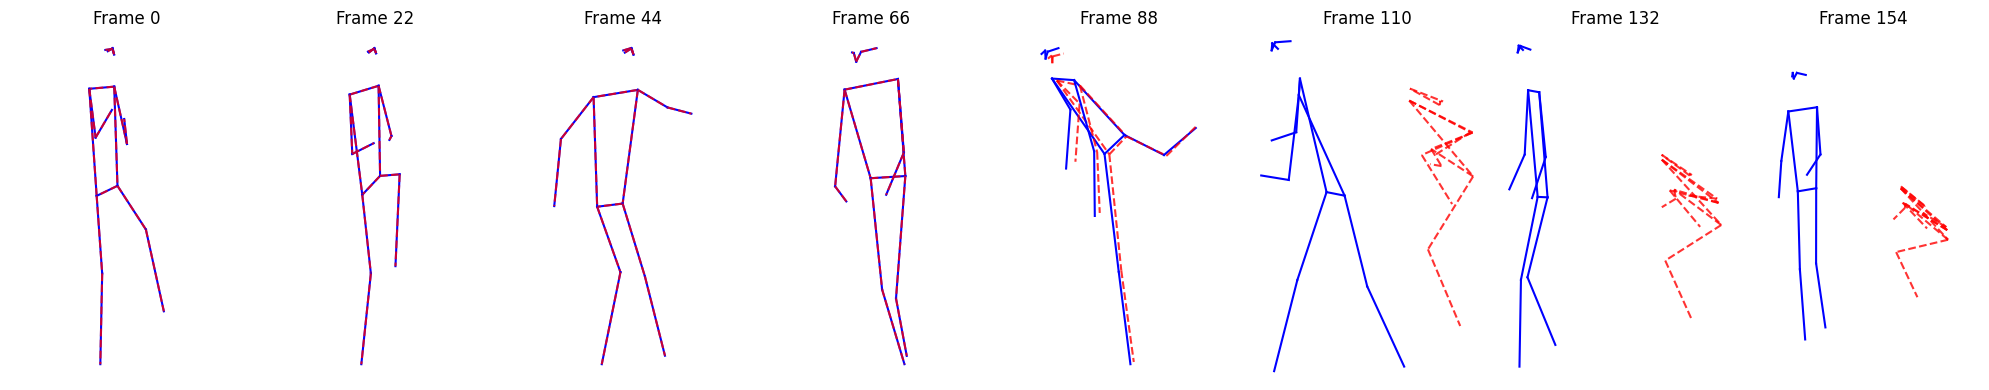

In [ ]:
sample = test_data[0]['inputs'].unsqueeze(0).cuda() # Shape: [1, 180, 17, 4]
burn_in_steps = 88
forward_steps = 88 # Predict the rest of the sequence

model.eval()
with torch.no_grad():
    # Model uses first 50 frames to understand the "physics" then predicts the rest
    predictions = model.predict_future(sample[:, :burn_in_steps], forward_steps)
    # Combine burn-in (actual) and predictions for a full sequence
    full_prediction = torch.cat([sample[:, :burn_in_steps].cpu(), predictions.cpu()], dim=1).squeeze(0)

actual = sample.squeeze(0).cpu()

# Plotting Comparison
plt.figure(figsize=(20, 4))
for idx, frame_num in enumerate(range(0, DATA_LEN, DATA_LEN//8), 1):
    ax = plt.subplot(1, 8, idx)
    
    # Coordinates
    pos_act = actual[frame_num, :, :2].numpy()
    pos_pred = full_prediction[frame_num, :, :2].numpy()

    for i, j in coco_connections:
        # Plot Actual (Blue)
        ax.plot([pos_act[i, 0], pos_act[j, 0]], [pos_act[i, 1], pos_act[j, 1]], 
                color='blue', alpha=1, label='Actual' if idx==1 else "")
        # Plot Prediction (Red)
        ax.plot([pos_pred[i, 0], pos_pred[j, 0]], [pos_pred[i, 1], pos_pred[j, 1]], 
                color='red', linestyle='--', alpha=0.8, label='Predicted' if idx==1 else "")

    ax.set_title(f'Frame {frame_num}')
    ax.axis('equal')
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()